In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.linalg import solve_triangular
import matplotlib.pyplot as plt

import gpjax as gpx

from non_parametric_pro.density import ProParameters, pro_logdensity_grad_fn
from non_parametric_pro.ula import pro_ula
from non_parametric_pro.util import predictive_moments, posterior_function_draws

from blackjax.util import run_inference_algorithm

jax.config.update("jax_enable_x64", True)

In [2]:
key = jr.key(0)

n = 50
noise = 0.3

key, subkey = jr.split(key)
x_train = jr.uniform(key=key, minval=-3.0, maxval=3.0, shape=(n,)).reshape(-1, 1)
f = lambda x: jnp.sin(4 * x) + jnp.cos(2 * x)
signal = f(x_train)
y_train = signal + jr.normal(subkey, shape=signal.shape) * noise

D = gpx.Dataset(X=x_train, y=y_train)

x_test = jnp.linspace(-3.5, 3.5, 200).reshape(-1, 1)
y_test = f(x_test)

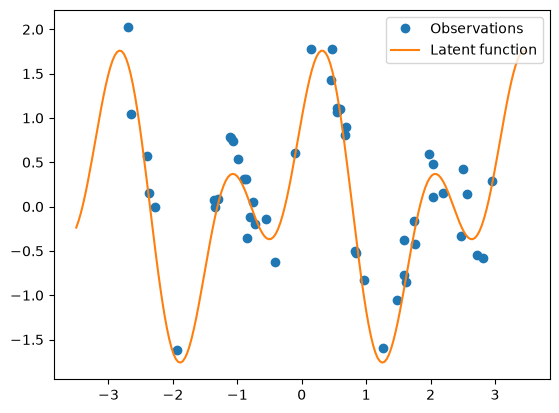

In [3]:
fig, ax = plt.subplots()
ax.plot(x_train, y_train, "o", label="Observations")
ax.plot(x_test, y_test, label="Latent function")
ax.legend(loc="best")
plt.show()

In [4]:
m = n   # number of basis functions
j = 30   # number of particles
jitter = 1e-5

k = gpx.kernels.Matern32(lengthscale=0.5)
K_train = k.gram(x_train).as_matrix()
train_basis = jnp.linalg.cholesky(K_train + jitter * jnp.eye(K_train.shape[0]))

position = jr.normal(key, (m, j))

params = ProParameters(
    y=y_train,
    basis=train_basis,
    step_size=1e-3,
    nu=0.2,
    alpha=1.0,
    tolerance=1e-200,
    jitter=1e-5,
)

ula = pro_ula(pro_logdensity_grad_fn, params)

out, history = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=ula,
    num_steps=20000,
    initial_position=position,
    progress_bar=True
)

particles = out.position

<div><progress max="20000" value="20000"></progress> 100.00% [20000/20000 00:00&lt;?]</div>

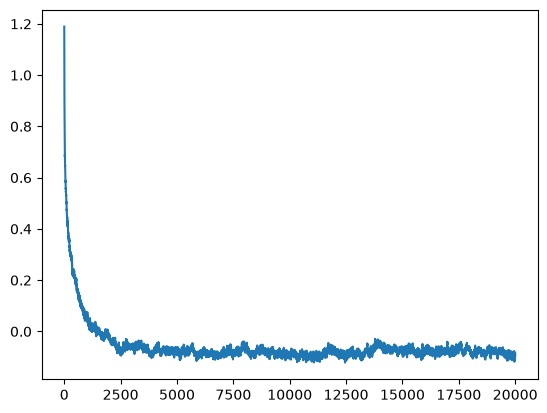

In [5]:
plt.plot(history[1].score)
plt.show()

In [6]:
K_test_train = k.cross_covariance(x_test, x_train)
test_basis = solve_triangular(train_basis, K_test_train.T, lower=True).T
test_cov = k.gram(x_test).as_matrix()

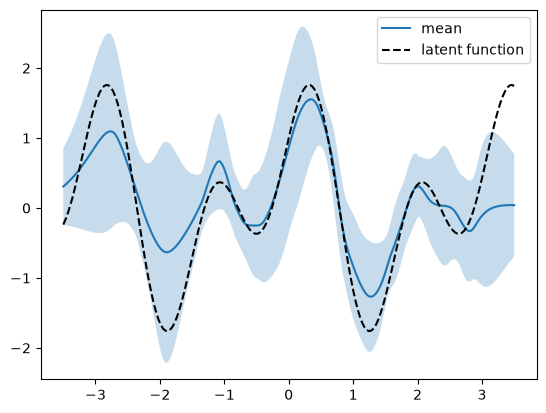

In [7]:
mean, std = predictive_moments(test_basis, out.position, noise_std=params.nu)

x_plot = x_test.squeeze()

plt.plot(x_plot, mean, label="mean")
plt.fill_between(x_plot, mean - 1.64 * std, mean + 1.64 * std, alpha=0.25)
plt.plot(x_test.squeeze(), y_test.squeeze(), color="black", label="latent function", linestyle="--")
plt.legend()
plt.show()

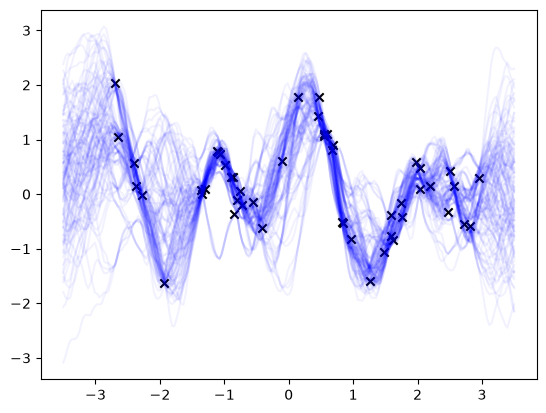

In [8]:
draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    particles,
    num_draws=120,
    jitter=1e-6,
)

plt.plot(x_test.squeeze(), draws, color="blue", alpha=0.05)
plt.scatter(x_train.squeeze(), y_train.squeeze(), color="black", label="observations", marker="x")
plt.show()